# Evaluación final en test

Este notebook evalúa exclusivamente las familias seleccionadas y congeladas mediante el conjunto de validación.

Las configuraciones se cargan desde `resultados/seleccion_familias_test.csv`. Los resultados de test no se utilizarán para modificar la representación, normalización, inicialización, optimizador ni número de componentes.

In [1]:
from itertools import combinations
from pathlib import Path
from time import perf_counter
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.optimize import nnls

In [2]:
# Ruta principal del proyecto
def encontrar_raiz_proyecto():
    """Busca la raíz del proyecto desde el directorio actual."""

    ruta_actual = Path.cwd().resolve()

    for ruta_candidata in (
        ruta_actual,
        *ruta_actual.parents,
    ):
        tiene_src = (
            ruta_candidata
            / "src"
        ).is_dir()

        tiene_notebooks = (
            ruta_candidata
            / "notebooks"
        ).is_dir()

        if tiene_src and tiene_notebooks:
            return ruta_candidata

    raise FileNotFoundError(
        "No se encontró la raíz del proyecto."
    )


RUTA_PROYECTO = encontrar_raiz_proyecto()

print(
    "Raíz del proyecto:",
    RUTA_PROYECTO,
)


# Permitir que Python encuentre los módulos de src
if str(RUTA_PROYECTO) not in sys.path:
    sys.path.insert(
        0,
        str(RUTA_PROYECTO),
    )


from src.loaders import cargar_dataset
from src.metricas import (
    ari_metric,
    calcular_metricas_ejecucion,
)
from src.normalizacion import aplicar_normalizacion

Raíz del proyecto: C:\Users\adanm\Code\tesis


In [2]:
RUTA_REGISTRO = (
    RUTA_PROYECTO
    / "resultados"
    / "registro_experimentos.csv"
)

RUTA_SELECCION_ORIGINAL = (
    RUTA_PROYECTO
    / "resultados"
    / "seleccion_familias_test.csv"
)

RUTA_SELECCION_CORREGIDA = (
    RUTA_PROYECTO
    / "resultados"
    / "seleccion_familias_test_corregida.csv"
)

df_registro = pd.read_csv(RUTA_REGISTRO)
df_seleccion_original = pd.read_csv(RUTA_SELECCION_ORIGINAL)

kmeans_k5_correcto = (
    df_registro.loc[
        (df_registro["modelo"] == "kmeans")
        & (df_registro["dataset"] == "medianas_fase_50")
        & (df_registro["normalizacion"] == "minmax")
        & (df_registro["inicializacion"] == "k-means++")
        & (df_registro["K"] == 5)
        & (df_registro["seed_modelo"].isin([0, 1, 2, 3, 4]))
    ]
    .copy()
)

if len(kmeans_k5_correcto) != 5:
    raise ValueError(
        "No se encontraron exactamente cinco ejecuciones correctas."
    )

kmeans_k5_correcto["familia_test"] = "kmeans_comparacion_k5"

kmeans_k5_correcto = kmeans_k5_correcto[
    df_seleccion_original.columns
]

df_seleccion_corregida = pd.concat(
    [
        df_seleccion_original.loc[
            df_seleccion_original["familia_test"]
            != "kmeans_comparacion_k5"
        ],
        kmeans_k5_correcto,
    ],
    ignore_index=True,
)

df_seleccion_corregida = (
    df_seleccion_corregida
    .sort_values(["familia_test", "seed_modelo"])
    .reset_index(drop=True)
)

df_seleccion_corregida.to_csv(
    RUTA_SELECCION_CORREGIDA,
    index=False,
)

display(
    df_seleccion_corregida[
        [
            "familia_test",
            "experiment_id",
            "normalizacion",
            "K",
            "seed_modelo",
        ]
    ]
)

,familia_test,experiment_id,normalizacion,K,seed_modelo
0,aa_principal_k5,130b477559867762,minmax,5,0
1,aa_principal_k5,4dd949ada25b888e,minmax,5,1
2,aa_principal_k5,37dedb2834a007b2,minmax,5,2
3,aa_principal_k5,349e82cdd54799e0,minmax,5,3
4,aa_principal_k5,976409505a67e4f6,minmax,5,4
5,kmeans_comparacion_k5,a50d5ee7f3724c42,minmax,5,0
6,kmeans_comparacion_k5,9ea73bea4e48a1be,minmax,5,1
7,kmeans_comparacion_k5,bab52ec2e2b2b05e,minmax,5,2
8,kmeans_comparacion_k5,0e3ab51d5d164b07,minmax,5,3
9,kmeans_comparacion_k5,b35af81b5b6f2d41,minmax,5,4


In [3]:
# Ruta del archivo con las familias seleccionadas
RUTA_SELECCION_TEST = (
    RUTA_PROYECTO
    / "resultados"
    / "seleccion_familias_test_corregida.csv"
)


# Comprobar que el archivo exista
if not RUTA_SELECCION_TEST.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo:\n{RUTA_SELECCION_TEST}"
    )


# Cargar las 15 ejecuciones seleccionadas
df_seleccion_test = pd.read_csv(
    RUTA_SELECCION_TEST
)


# Resumir las ejecuciones de cada familia
resumen_seleccion = (
    df_seleccion_test
    .groupby("familia_test")
    .agg(
        n_ejecuciones=("experiment_id", "size"),
        n_semillas=("seed_modelo", "nunique"),
        semillas=(
            "seed_modelo",
            lambda valores: sorted(valores.tolist()),
        ),
    )
)


print(
    f"Dimensiones de la selección: "
    f"{df_seleccion_test.shape}"
)

display(resumen_seleccion)

Dimensiones de la selección: (15, 10)


,n_ejecuciones,n_semillas,semillas
familia_test,,,
aa_principal_k5,5,5,"[0, 1, 2, 3, 4]"
kmeans_comparacion_k5,5,5,"[0, 1, 2, 3, 4]"
kmeans_principal_k4,5,5,"[0, 1, 2, 3, 4]"


In [4]:
# Artefactos necesarios para verificar y proyectar las ejecuciones
artefactos_requeridos = [
    "patrones.npy",
    "grupos_val.npy",
    "ids_val.npy",
]


# Revisar las 15 carpetas seleccionadas
revision_artefactos = []

for _, ejecucion in df_seleccion_test.iterrows():

    carpeta_experimento = (
        RUTA_PROYECTO
        / Path(ejecucion["ruta_experimento"])
    )

    archivos_faltantes = [
        archivo
        for archivo in artefactos_requeridos
        if not (carpeta_experimento / archivo).exists()
    ]

    revision_artefactos.append(
        {
            "familia_test": ejecucion["familia_test"],
            "experiment_id": ejecucion["experiment_id"],
            "carpeta_existe": carpeta_experimento.exists(),
            "n_artefactos_faltantes": len(archivos_faltantes),
            "artefactos_faltantes": archivos_faltantes,
        }
    )


df_revision_artefactos = pd.DataFrame(
    revision_artefactos
)


resumen_artefactos = (
    df_revision_artefactos
    .groupby(
        [
            "carpeta_existe",
            "n_artefactos_faltantes",
        ]
    )
    .size()
    .rename("n_ejecuciones")
)


display(resumen_artefactos)

carpeta_existe  n_artefactos_faltantes
True            0                         15
Name: n_ejecuciones, dtype: int64

In [5]:
# Cargar el dataset compartido por las tres familias
datos_mediana_50 = cargar_dataset(
    "medianas_fase_50"
)

# Recuperar validación sin normalizar
X_val_original = datos_mediana_50["val"]["X"]

metadata_val = (
    datos_mediana_50["val"]["metadata"]
    .reset_index(drop=True)
    .copy()
)

# Preparar las normalizaciones utilizadas por K-Means
X_val_kmeans_por_normalizacion = {
    "zscore": aplicar_normalizacion(
        X_val_original,
        "zscore",
    ),
    "minmax": aplicar_normalizacion(
        X_val_original,
        "minmax",
    ),
}

# AA utiliza Min-Max
X_val_aa = X_val_kmeans_por_normalizacion["minmax"]

print(f"Validación original: {X_val_original.shape}")
print(
    "Validación K-Means Z-score: "
    f"{X_val_kmeans_por_normalizacion['zscore'].shape}"
)
print(
    "Validación K-Means Min-Max: "
    f"{X_val_kmeans_por_normalizacion['minmax'].shape}"
)
print(f"Validación para AA: {X_val_aa.shape}")
print(f"Filas de metadatos: {len(metadata_val)}")

Validación original: (20576, 50)
Validación K-Means Z-score: (20576, 50)
Validación K-Means Min-Max: (20576, 50)
Validación para AA: (20576, 50)
Filas de metadatos: 20576


In [6]:
def proyectar_kmeans(X, centroides):
    """
    Asignar cada curva al centroide euclidiano más cercano
    y reconstruirla mediante ese centroide.
    """
    X = np.asarray(X, dtype=np.float64)
    centroides = np.asarray(
        centroides,
        dtype=np.float64,
    )

    distancias_cuadradas = (
        np.sum(X ** 2, axis=1, keepdims=True)
        + np.sum(centroides ** 2, axis=1)
        - 2 * X @ centroides.T
    )

    grupos = np.argmin(
        distancias_cuadradas,
        axis=1,
    )

    X_reconstruida = centroides[grupos]

    return grupos, X_reconstruida

In [7]:
# Seleccionar las ejecuciones de K-Means
df_kmeans_test = (
    df_seleccion_test
    .loc[df_seleccion_test["modelo"] == "kmeans"]
    .copy()
)


comprobaciones_kmeans = []

for _, ejecucion in df_kmeans_test.iterrows():

    carpeta_experimento = (
        RUTA_PROYECTO
        / Path(ejecucion["ruta_experimento"])
    )

    centroides = np.load(
        carpeta_experimento / "patrones.npy"
    )

    grupos_val_guardados = np.load(
        carpeta_experimento / "grupos_val.npy"
    )

    ids_val_guardados = np.load(
        carpeta_experimento / "ids_val.npy",
        allow_pickle=True,
    )

    ids_val_actuales = (
        metadata_val["observacion_id"]
        .to_numpy()
    )

    mismos_ids = np.array_equal(
        ids_val_actuales,
        ids_val_guardados,
    )

    # Utilizar la normalización correspondiente a cada ejecución
    X_val_kmeans = X_val_kmeans_por_normalizacion[
        ejecucion["normalizacion"]
    ]

    grupos_val_reproducidos, _ = proyectar_kmeans(
        X=X_val_kmeans,
        centroides=centroides,
    )

    n_asignaciones_distintas = int(
        np.sum(
            grupos_val_reproducidos
            != grupos_val_guardados
        )
    )

    ari_reproduccion = ari_metric(
        grupos_val_guardados,
        grupos_val_reproducidos,
    )

    comprobaciones_kmeans.append(
        {
            "familia_test": ejecucion["familia_test"],
            "seed_modelo": ejecucion["seed_modelo"],
            "normalizacion": ejecucion["normalizacion"],
            "mismos_ids": mismos_ids,
            "n_asignaciones_distintas": (
                n_asignaciones_distintas
            ),
            "ari_reproduccion": ari_reproduccion,
        }
    )


df_comprobacion_kmeans = pd.DataFrame(
    comprobaciones_kmeans
)

display(df_comprobacion_kmeans)

,familia_test,seed_modelo,normalizacion,mismos_ids,n_asignaciones_distintas,ari_reproduccion
0,kmeans_comparacion_k5,0,minmax,True,0,1.0
1,kmeans_comparacion_k5,1,minmax,True,0,1.0
2,kmeans_comparacion_k5,2,minmax,True,0,1.0
3,kmeans_comparacion_k5,3,minmax,True,0,1.0
4,kmeans_comparacion_k5,4,minmax,True,0,1.0
5,kmeans_principal_k4,0,zscore,True,0,1.0
6,kmeans_principal_k4,1,zscore,True,0,1.0
7,kmeans_principal_k4,2,zscore,True,0,1.0
8,kmeans_principal_k4,3,zscore,True,0,1.0
9,kmeans_principal_k4,4,zscore,True,0,1.0


In [8]:
def proyectar_aa_nnls(
    X,
    arquetipos,
    constante=100.0,
    max_iter=100,
):
    """
    Proyectar curvas sobre arquetipos fijos mediante NNLS.

    La fila adicional impone aproximadamente que los
    coeficientes sumen uno. Después se normalizan para
    asegurar la pertenencia al simplex.
    """
    X = np.asarray(
        X,
        dtype=np.float64,
    )

    arquetipos = np.asarray(
        arquetipos,
        dtype=np.float64,
    )

    n_curvas = X.shape[0]
    n_arquetipos = arquetipos.shape[0]

    matriz_nnls = np.vstack(
        [
            arquetipos.T,
            constante * np.ones(
                (1, n_arquetipos)
            ),
        ]
    )

    coeficientes = np.empty(
        (n_curvas, n_arquetipos),
        dtype=np.float64,
    )

    for indice, curva in enumerate(X):

        vector_nnls = np.concatenate(
            [
                curva,
                np.array([constante]),
            ]
        )

        coeficientes_curva, _ = nnls(
            matriz_nnls,
            vector_nnls,
            maxiter=max_iter,
        )

        suma = coeficientes_curva.sum()

        if suma <= 0:
            raise ValueError(
                f"Los coeficientes de la curva {indice} "
                "no tienen una suma positiva."
            )

        coeficientes[indice] = (
            coeficientes_curva / suma
        )

    grupos = np.argmax(
        coeficientes,
        axis=1,
    )

    X_reconstruida = (
        coeficientes @ arquetipos
    )

    return (
        coeficientes,
        grupos,
        X_reconstruida,
    )

In [9]:
# Seleccionar una ejecución AA para validar la proyección
ejecucion_aa_validacion = (
    df_seleccion_test
    .loc[
        (df_seleccion_test["familia_test"] == "aa_principal_k5")
        & (df_seleccion_test["seed_modelo"] == 0)
    ]
    .iloc[0]
)


carpeta_aa_validacion = (
    RUTA_PROYECTO
    / Path(ejecucion_aa_validacion["ruta_experimento"])
)


# Cargar los resultados guardados durante el experimento
arquetipos = np.load(
    carpeta_aa_validacion / "patrones.npy"
)

alphas_val_guardados = np.load(
    carpeta_aa_validacion / "alphas_val.npy"
)

grupos_val_guardados = np.load(
    carpeta_aa_validacion / "grupos_val.npy"
)

ids_val_guardados = np.load(
    carpeta_aa_validacion / "ids_val.npy",
    allow_pickle=True,
)


# Comprobar el orden de las curvas
ids_val_actuales = (
    metadata_val["observacion_id"]
    .to_numpy()
)

mismos_ids_aa = np.array_equal(
    ids_val_actuales,
    ids_val_guardados,
)


# Reproducir la proyección de validación
inicio = perf_counter()

(
    alphas_val_reproducidos,
    grupos_val_reproducidos,
    X_val_reconstruida_aa,
) = proyectar_aa_nnls(
    X=X_val_aa,
    arquetipos=arquetipos,
    constante=100.0,
    max_iter=1000,
)

tiempo_proyeccion = perf_counter() - inicio


# Comparar con los artefactos guardados
diferencia_alphas = np.abs(
    alphas_val_reproducidos
    - alphas_val_guardados
)

n_grupos_distintos = int(
    np.sum(
        grupos_val_reproducidos
        != grupos_val_guardados
    )
)


print(f"Mismos IDs: {mismos_ids_aa}")
print(f"Tiempo de proyección: {tiempo_proyeccion:.2f} segundos")

print(
    "Diferencia máxima entre alphas: "
    f"{diferencia_alphas.max():.10f}"
)

print(
    "Diferencia media entre alphas: "
    f"{diferencia_alphas.mean():.10f}"
)

print(
    f"Asignaciones diferentes: {n_grupos_distintos}"
)

print(
    "ARI de reproducción: "
    f"{ari_metric(grupos_val_guardados, grupos_val_reproducidos):.10f}"
)

print(
    "Rango de las sumas de alphas: "
    f"[{alphas_val_reproducidos.sum(axis=1).min():.10f}, "
    f"{alphas_val_reproducidos.sum(axis=1).max():.10f}]"
)

Mismos IDs: True
Tiempo de proyección: 0.38 segundos
Diferencia máxima entre alphas: 0.0000000400
Diferencia media entre alphas: 0.0000000071
Asignaciones diferentes: 0
ARI de reproducción: 1.0000000000
Rango de las sumas de alphas: [1.0000000000, 1.0000000000]


In [10]:
# Recuperar el conjunto de test
X_test_original = datos_mediana_50["test"]["X"]

metadata_test = (
    datos_mediana_50["test"]["metadata"]
    .reset_index(drop=True)
    .copy()
)

# Preparar las normalizaciones utilizadas por K-Means
X_test_kmeans_por_normalizacion = {
    "zscore": aplicar_normalizacion(
        X_test_original,
        "zscore",
    ),
    "minmax": aplicar_normalizacion(
        X_test_original,
        "minmax",
    ),
}

# AA utiliza Min-Max
X_test_aa = X_test_kmeans_por_normalizacion["minmax"]

# Comprobar la correspondencia entre curvas y metadatos
if len(metadata_test) != X_test_original.shape[0]:
    raise ValueError(
        "La cantidad de metadatos no coincide "
        "con la cantidad de curvas de test."
    )

# Comprobar ambas normalizaciones de K-Means
for normalizacion, matriz in (
    X_test_kmeans_por_normalizacion.items()
):
    if not np.isfinite(matriz).all():
        raise ValueError(
            "Test normalizado para K-Means contiene "
            f"valores no finitos con {normalizacion}."
        )

# Comprobar la matriz utilizada por AA
if not np.isfinite(X_test_aa).all():
    raise ValueError(
        "Test normalizado para AA contiene "
        "valores no finitos."
    )

if metadata_test["observacion_id"].duplicated().any():
    raise ValueError(
        "Test contiene observacion_id duplicados."
    )

print(f"Test original: {X_test_original.shape}")
print(
    "Test K-Means Z-score: "
    f"{X_test_kmeans_por_normalizacion['zscore'].shape}"
)
print(
    "Test K-Means Min-Max: "
    f"{X_test_kmeans_por_normalizacion['minmax'].shape}"
)
print(f"Test para AA: {X_test_aa.shape}")
print(f"Filas de metadatos: {len(metadata_test)}")
print(
    "Observaciones únicas: "
    f"{metadata_test['observacion_id'].nunique()}"
)

Test original: (20537, 50)
Test K-Means Z-score: (20537, 50)
Test K-Means Min-Max: (20537, 50)
Test para AA: (20537, 50)
Filas de metadatos: 20537
Observaciones únicas: 20537


In [11]:
# Etiquetas astronómicas de test
subtipos_test = (
    metadata_test["subtipo_rrlyrae"]
    .to_numpy()
)


resultados_test_kmeans = []
grupos_test_kmeans = {}


inicio_kmeans = perf_counter()


for _, ejecucion in df_kmeans_test.iterrows():

    carpeta_experimento = (
        RUTA_PROYECTO
        / Path(ejecucion["ruta_experimento"])
    )

    centroides = np.load(
        carpeta_experimento / "patrones.npy"
    )

    # Utilizar la normalización correspondiente a cada ejecución
    X_test_kmeans = X_test_kmeans_por_normalizacion[
        ejecucion["normalizacion"]
    ]

    grupos_test, X_test_reconstruida = proyectar_kmeans(
        X=X_test_kmeans,
        centroides=centroides,
    )

    metricas_test = calcular_metricas_ejecucion(
        X=X_test_kmeans,
        X_reconstruida=X_test_reconstruida,
        subtipos=subtipos_test,
        grupos=grupos_test,
        silhouette_n_muestras=5000,
        silhouette_seed=42,
    )

    experiment_id = ejecucion["experiment_id"]

    grupos_test_kmeans[experiment_id] = grupos_test

    resultados_test_kmeans.append(
        {
            "familia_test": ejecucion["familia_test"],
            "experiment_id": experiment_id,
            "modelo": ejecucion["modelo"],
            "K": ejecucion["K"],
            "seed_modelo": ejecucion["seed_modelo"],
            **{
                f"{nombre}_test": valor
                for nombre, valor in metricas_test.items()
            },
        }
    )


tiempo_kmeans = perf_counter() - inicio_kmeans


df_resultados_test_kmeans = pd.DataFrame(
    resultados_test_kmeans
).sort_values(
    ["familia_test", "seed_modelo"]
).reset_index(drop=True)


print(
    "Tiempo total de evaluación de K-Means: "
    f"{tiempo_kmeans:.2f} segundos"
)

display(df_resultados_test_kmeans)

Tiempo total de evaluación de K-Means: 6.77 segundos


,familia_test,experiment_id,modelo,K,seed_modelo,mse_test,rss_test,purity_test,davies_bouldin_test,silhouette_test,ami_test
0,kmeans_comparacion_k5,a50d5ee7f3724c42,kmeans,5,0,0.006482,6656.319560,0.919755,1.433957,0.232516,0.404495
1,kmeans_comparacion_k5,9ea73bea4e48a1be,kmeans,5,1,0.006540,6715.958057,0.899791,1.359874,0.286770,0.417680
2,kmeans_comparacion_k5,bab52ec2e2b2b05e,kmeans,5,2,0.006483,6656.857358,0.919706,1.434634,0.232231,0.404608
3,kmeans_comparacion_k5,0e3ab51d5d164b07,kmeans,5,3,0.006483,6656.820779,0.919706,1.434605,0.232236,0.404594
4,kmeans_comparacion_k5,b35af81b5b6f2d41,kmeans,5,4,0.006483,6656.847455,0.919706,1.434634,0.232231,0.404608
5,kmeans_principal_k4,a2314adca1d6413e,kmeans,4,0,0.059282,60873.772861,0.911866,1.283114,0.308365,0.453525
6,kmeans_principal_k4,bb069387774f6b3b,kmeans,4,1,0.059282,60873.242269,0.911866,1.283149,0.308249,0.453494
7,kmeans_principal_k4,ea983d5d0b8864c8,kmeans,4,2,0.059279,60870.926226,0.912159,1.282982,0.308622,0.453622
8,kmeans_principal_k4,a1a7966d1e8b0140,kmeans,4,3,0.059282,60873.772861,0.911866,1.283114,0.308365,0.453525
9,kmeans_principal_k4,ff9087d76ac9a750,kmeans,4,4,0.059282,60873.772861,0.911866,1.283114,0.308365,0.453525


In [12]:
# Comprobar la integridad de los resultados de K-Means
columnas_metricas_test = [
    "mse_test",
    "rss_test",
    "purity_test",
    "davies_bouldin_test",
    "silhouette_test",
    "ami_test",
]

if len(df_resultados_test_kmeans) != 10:
    raise ValueError(
        "Se esperaban diez ejecuciones de K-Means."
    )

if not np.isfinite(
    df_resultados_test_kmeans[columnas_metricas_test]
    .to_numpy()
).all():
    raise ValueError(
        "Existen métricas no finitas en K-Means."
    )


# Seleccionar las cinco ejecuciones de AA
df_aa_test = (
    df_seleccion_test
    .loc[
        df_seleccion_test["modelo"]
        == "archetypal_analysis"
    ]
    .copy()
)


resultados_test_aa = []
grupos_test_aa = {}
alphas_test_aa = {}


inicio_aa = perf_counter()


for _, ejecucion in df_aa_test.iterrows():

    carpeta_experimento = (
        RUTA_PROYECTO
        / Path(ejecucion["ruta_experimento"])
    )

    arquetipos = np.load(
        carpeta_experimento / "patrones.npy"
    )

    inicio_ejecucion = perf_counter()

    (
        alphas_test,
        grupos_test,
        X_test_reconstruida,
    ) = proyectar_aa_nnls(
        X=X_test_aa,
        arquetipos=arquetipos,
        constante=100.0,
        max_iter=1000,
    )

    tiempo_proyeccion = (
        perf_counter() - inicio_ejecucion
    )

    metricas_test = calcular_metricas_ejecucion(
        X=X_test_aa,
        X_reconstruida=X_test_reconstruida,
        subtipos=subtipos_test,
        grupos=grupos_test,
        silhouette_n_muestras=5000,
        silhouette_seed=42,
    )

    experiment_id = ejecucion["experiment_id"]

    grupos_test_aa[experiment_id] = grupos_test
    alphas_test_aa[experiment_id] = alphas_test

    resultados_test_aa.append(
        {
            "familia_test": ejecucion["familia_test"],
            "experiment_id": experiment_id,
            "modelo": ejecucion["modelo"],
            "K": ejecucion["K"],
            "seed_modelo": ejecucion["seed_modelo"],
            "tiempo_proyeccion_segundos": tiempo_proyeccion,
            **{
                f"{nombre}_test": valor
                for nombre, valor in metricas_test.items()
            },
        }
    )


tiempo_aa = perf_counter() - inicio_aa


df_resultados_test_aa = (
    pd.DataFrame(resultados_test_aa)
    .sort_values("seed_modelo")
    .reset_index(drop=True)
)


print(
    "Tiempo total de evaluación de AA: "
    f"{tiempo_aa:.2f} segundos"
)

display(df_resultados_test_aa)

Tiempo total de evaluación de AA: 5.40 segundos


,familia_test,experiment_id,modelo,K,seed_modelo,tiempo_proyeccion_segundos,mse_test,rss_test,purity_test,davies_bouldin_test,silhouette_test,ami_test
0,aa_principal_k5,130b477559867762,archetypal_analysis,5,0,0.327179,0.004019,4126.604483,0.925744,1.562578,0.241399,0.399344
1,aa_principal_k5,4dd949ada25b888e,archetypal_analysis,5,1,0.410193,0.004019,4126.604498,0.925744,1.562578,0.241399,0.399344
2,aa_principal_k5,37dedb2834a007b2,archetypal_analysis,5,2,0.584320,0.004019,4126.547504,0.925792,1.562653,0.241399,0.399394
3,aa_principal_k5,349e82cdd54799e0,archetypal_analysis,5,3,0.313848,0.004019,4126.547504,0.925792,1.562653,0.241399,0.399394
4,aa_principal_k5,976409505a67e4f6,archetypal_analysis,5,4,0.334939,0.004019,4126.604490,0.925744,1.562578,0.241399,0.399344


In [13]:
# Comprobar la integridad de los resultados de AA
if len(df_resultados_test_aa) != 5:
    raise ValueError(
        "Se esperaban cinco ejecuciones de AA."
    )

if not np.isfinite(
    df_resultados_test_aa[columnas_metricas_test]
    .to_numpy()
).all():
    raise ValueError(
        "Existen métricas no finitas en AA."
    )


# Unir las 15 evaluaciones individuales
df_resultados_test = pd.concat(
    [
        df_resultados_test_kmeans,
        df_resultados_test_aa,
    ],
    ignore_index=True,
    sort=False,
)


# Resumir cada familia mediante sus cinco semillas
df_resumen_test = (
    df_resultados_test
    .groupby(
        [
            "familia_test",
            "modelo",
            "K",
        ],
        as_index=False,
    )
    .agg(
        n_ejecuciones=("experiment_id", "size"),

        mse_test_media=("mse_test", "mean"),
        mse_test_std=("mse_test", "std"),

        rss_test_media=("rss_test", "mean"),
        rss_test_std=("rss_test", "std"),

        purity_test_media=("purity_test", "mean"),
        purity_test_std=("purity_test", "std"),

        davies_bouldin_test_media=(
            "davies_bouldin_test",
            "mean",
        ),
        davies_bouldin_test_std=(
            "davies_bouldin_test",
            "std",
        ),

        silhouette_test_media=(
            "silhouette_test",
            "mean",
        ),
        silhouette_test_std=(
            "silhouette_test",
            "std",
        ),

        ami_test_media=("ami_test", "mean"),
        ami_test_std=("ami_test", "std"),
    )
)


display(df_resumen_test)

,familia_test,modelo,K,n_ejecuciones,mse_test_media,mse_test_std,rss_test_media,rss_test_std,purity_test_media,purity_test_std,davies_bouldin_test_media,davies_bouldin_test_std,silhouette_test_media,silhouette_test_std,ami_test_media,ami_test_std
0,aa_principal_k5,archetypal_analysis,5,5,0.004019,3.039655e-08,4126.581696,0.031213,0.925763,0.000027,1.562608,0.000041,0.241399,0.000000,0.399364,0.000028
1,kmeans_comparacion_k5,kmeans,5,5,0.006494,2.580409e-05,6668.560642,26.496929,0.915733,0.008912,1.419541,0.033356,0.243197,0.024358,0.407197,0.005860
2,kmeans_principal_k4,kmeans,4,5,0.059281,1.202986e-06,60873.097415,1.235286,0.911925,0.000131,1.283095,0.000065,0.308394,0.000137,0.453539,0.000049


In [14]:
# Reunir las asignaciones de las 15 ejecuciones
grupos_test_por_experimento = {
    **grupos_test_kmeans,
    **grupos_test_aa,
}


ari_test_detalle = []


for familia_test, grupo_familia in (
    df_seleccion_test.groupby("familia_test")
):

    ejecuciones = list(
        grupo_familia[
            [
                "experiment_id",
                "seed_modelo",
            ]
        ].itertuples(index=False, name=None)
    )

    for (
        experiment_id_a,
        seed_a,
    ), (
        experiment_id_b,
        seed_b,
    ) in combinations(ejecuciones, 2):

        ari = ari_metric(
            grupos_test_por_experimento[experiment_id_a],
            grupos_test_por_experimento[experiment_id_b],
        )

        ari_test_detalle.append(
            {
                "familia_test": familia_test,
                "seed_a": seed_a,
                "seed_b": seed_b,
                "ari_test": ari,
            }
        )


df_ari_test_detalle = pd.DataFrame(
    ari_test_detalle
)


df_ari_test_resumen = (
    df_ari_test_detalle
    .groupby("familia_test", as_index=False)
    .agg(
        n_comparaciones=("ari_test", "size"),
        ari_test_media=("ari_test", "mean"),
        ari_test_std=("ari_test", "std"),
        ari_test_min=("ari_test", "min"),
        ari_test_max=("ari_test", "max"),
    )
)


display(df_ari_test_resumen)

,familia_test,n_comparaciones,ari_test_media,ari_test_std,ari_test_min,ari_test_max
0,aa_principal_k5,10,0.999736,0.000228,0.999559,1.0
1,kmeans_comparacion_k5,10,0.784907,0.272469,0.468216,1.0
2,kmeans_principal_k4,10,0.998382,0.001628,0.995955,1.0


In [15]:
# Directorio de resultados de la evaluación final
RUTA_RESULTADOS_TEST = (
    RUTA_PROYECTO
    / "resultados"
    / "evaluacion_test_corregida"
)

RUTA_ARTEFACTOS_TEST = (
    RUTA_RESULTADOS_TEST
    / "artefactos"
)

RUTA_RESULTADOS_TEST.mkdir(
    parents=True,
    exist_ok=True,
)

RUTA_ARTEFACTOS_TEST.mkdir(
    parents=True,
    exist_ok=True,
)


# Incorporar la configuración completa a cada resultado
df_resultados_test_completo = (
    df_resultados_test
    .merge(
        df_seleccion_test,
        on=[
            "familia_test",
            "experiment_id",
            "modelo",
            "K",
            "seed_modelo",
        ],
        how="left",
        validate="one_to_one",
    )
)


# Incorporar estabilidad al resumen de métricas
df_resumen_test_completo = (
    df_resumen_test
    .merge(
        df_ari_test_resumen,
        on="familia_test",
        how="left",
        validate="one_to_one",
    )
)


# Guardar tablas
df_resultados_test_completo.to_csv(
    RUTA_RESULTADOS_TEST
    / "metricas_test_ejecuciones.csv",
    index=False,
)

df_resumen_test_completo.to_csv(
    RUTA_RESULTADOS_TEST
    / "metricas_test_resumen.csv",
    index=False,
)

df_ari_test_detalle.to_csv(
    RUTA_RESULTADOS_TEST
    / "ari_test_detalle.csv",
    index=False,
)

df_ari_test_resumen.to_csv(
    RUTA_RESULTADOS_TEST
    / "ari_test_resumen.csv",
    index=False,
)


# Guardar los identificadores de test una sola vez
np.save(
    RUTA_RESULTADOS_TEST / "ids_test.npy",
    metadata_test["observacion_id"].to_numpy(),
)


# Guardar asignaciones y coeficientes por ejecución
for experiment_id, grupos in (
    grupos_test_por_experimento.items()
):

    carpeta_salida = (
        RUTA_ARTEFACTOS_TEST
        / experiment_id
    )

    carpeta_salida.mkdir(
        parents=True,
        exist_ok=True,
    )

    np.save(
        carpeta_salida / "grupos_test.npy",
        grupos,
    )

    if experiment_id in alphas_test_aa:
        np.save(
            carpeta_salida / "alphas_test.npy",
            alphas_test_aa[experiment_id],
        )


print(
    f"Resultados guardados en:\n"
    f"{RUTA_RESULTADOS_TEST}"
)

print(
    f"\nEjecuciones guardadas: "
    f"{len(df_resultados_test_completo)}"
)

print(
    "Carpetas de artefactos: "
    f"{len(list(RUTA_ARTEFACTOS_TEST.iterdir()))}"
)

Resultados guardados en:
C:\Users\adanm\Code\tesis\resultados\evaluacion_test_corregida

Ejecuciones guardadas: 15
Carpetas de artefactos: 15


In [16]:
# Cargar el registro que contiene las métricas de validación
RUTA_REGISTRO = (
    RUTA_PROYECTO
    / "resultados"
    / "registro_experimentos.csv"
)

df_registro = pd.read_csv(
    RUTA_REGISTRO
)


# Recuperar validación para las 15 ejecuciones seleccionadas
df_validacion_seleccionada = (
    df_registro
    .loc[
        df_registro["experiment_id"].isin(
            df_seleccion_test["experiment_id"]
        )
    ]
    .merge(
        df_seleccion_test[
            [
                "experiment_id",
                "familia_test",
            ]
        ],
        on="experiment_id",
        how="inner",
        validate="one_to_one",
    )
)


# Resumir las métricas de validación por familia
df_resumen_validacion = (
    df_validacion_seleccionada
    .groupby("familia_test", as_index=False)
    .agg(
        mse_val_media=("mse_val", "mean"),
        purity_val_media=("purity_val", "mean"),
        davies_bouldin_val_media=(
            "davies_bouldin_val",
            "mean",
        ),
        silhouette_val_media=(
            "silhouette_val",
            "mean",
        ),
        ami_val_media=("ami_val", "mean"),
    )
)


# Unir validación y test
df_comparacion_val_test = (
    df_resumen_validacion
    .merge(
        df_resumen_test_completo[
            [
                "familia_test",
                "mse_test_media",
                "purity_test_media",
                "davies_bouldin_test_media",
                "silhouette_test_media",
                "ami_test_media",
            ]
        ],
        on="familia_test",
        how="inner",
        validate="one_to_one",
    )
)


# Calcular el cambio de validación a test
df_comparacion_val_test["cambio_mse_pct"] = (
    (
        df_comparacion_val_test["mse_test_media"]
        - df_comparacion_val_test["mse_val_media"]
    )
    / df_comparacion_val_test["mse_val_media"]
    * 100
)

for metrica in [
    "purity",
    "davies_bouldin",
    "silhouette",
    "ami",
]:
    df_comparacion_val_test[f"cambio_{metrica}"] = (
        df_comparacion_val_test[f"{metrica}_test_media"]
        - df_comparacion_val_test[f"{metrica}_val_media"]
    )


columnas_comparacion = [
    "familia_test",
    "cambio_mse_pct",
    "cambio_purity",
    "cambio_davies_bouldin",
    "cambio_silhouette",
    "cambio_ami",
]


display(
    df_comparacion_val_test[
        columnas_comparacion
    ]
)

,familia_test,cambio_mse_pct,cambio_purity,cambio_davies_bouldin,cambio_silhouette,cambio_ami
0,aa_principal_k5,1.049101,-0.002843,-0.009578,0.003914,0.004852
1,kmeans_comparacion_k5,0.739505,0.000035,-0.001986,0.007604,0.006012
2,kmeans_principal_k4,0.529436,0.001330,-0.001742,0.003996,0.006468


## Consistencia entre validación y test

Las métricas obtenidas en test mantuvieron un comportamiento consistente con el observado durante la validación. El MSE aumentó entre un 0,53 % y un 1,05 % según la familia, mientras que los cambios en pureza, Davies–Bouldin, silhouette y AMI fueron pequeños.

Las tres familias mejoraron ligeramente sus valores de Davies–Bouldin, silhouette y AMI en test. La pureza aumentó en 0,0013 para la familia principal de k-means con \(K=4\), permaneció prácticamente sin cambios para k-means con \(K=5\) y Min-Max, y disminuyó en 0,0028 para AA.

Estos resultados indican que las configuraciones seleccionadas conservaron en test el comportamiento observado durante la validación y que la selección no dependió de características particulares del conjunto de validación.

In [21]:
# Nombres legibles para las familias
nombres_familias = {
    "aa_principal_k5": "AA (K=5, Min-Max)",
    "kmeans_comparacion_k5": "k-means (K=5, Min-Max)",
    "kmeans_principal_k4": "k-means (K=4, Z-score)",
}


def formatear_media_std(tabla, columna_media, columna_std):
    """Mostrar una métrica como media ± desviación estándar."""
    return (
        tabla[columna_media].map(
            lambda valor: f"{valor:.4f}"
        )
        + " ± "
        + tabla[columna_std].map(
            lambda valor: f"{valor:.4f}"
        )
    )


# Partir desde el resumen numérico de test
tabla_final_mostrar = (
    df_resumen_test_completo
    .copy()
)


# Añadir nombres legibles
tabla_final_mostrar["familia"] = (
    tabla_final_mostrar["familia_test"]
    .map(nombres_familias)
)


# Formatear las métricas
tabla_final_mostrar["Pureza"] = formatear_media_std(
    tabla_final_mostrar,
    "purity_test_media",
    "purity_test_std",
)

tabla_final_mostrar["Davies–Bouldin"] = formatear_media_std(
    tabla_final_mostrar,
    "davies_bouldin_test_media",
    "davies_bouldin_test_std",
)

tabla_final_mostrar["Silhouette"] = formatear_media_std(
    tabla_final_mostrar,
    "silhouette_test_media",
    "silhouette_test_std",
)

tabla_final_mostrar["AMI"] = formatear_media_std(
    tabla_final_mostrar,
    "ami_test_media",
    "ami_test_std",
)

tabla_final_mostrar["ARI entre semillas"] = formatear_media_std(
    tabla_final_mostrar,
    "ari_test_media",
    "ari_test_std",
)


# Seleccionar y ordenar las columnas finales
tabla_final_mostrar = (
    tabla_final_mostrar
    .set_index("familia")
    .loc[
        [
            "k-means (K=4, Z-score)",
            "k-means (K=5, Min-Max)",
            "AA (K=5, Min-Max)",
        ],
        [
            "Pureza",
            "Davies–Bouldin",
            "Silhouette",
            "AMI",
            "ARI entre semillas",
        ],
    ]
    .reset_index()
)


display(tabla_final_mostrar)

,familia,Pureza,Davies–Bouldin,Silhouette,AMI,ARI entre semillas
0,"k-means (K=4, Z-score)",0.9119 ± 0.0001,1.2831 ± 0.0001,0.3084 ± 0.0001,0.4535 ± 0.0000,0.9984 ± 0.0016
1,"k-means (K=5, Min-Max)",0.9157 ± 0.0089,1.4195 ± 0.0334,0.2432 ± 0.0244,0.4072 ± 0.0059,0.7849 ± 0.2725
2,"AA (K=5, Min-Max)",0.9258 ± 0.0000,1.5626 ± 0.0000,0.2414 ± 0.0000,0.3994 ± 0.0000,0.9997 ± 0.0002


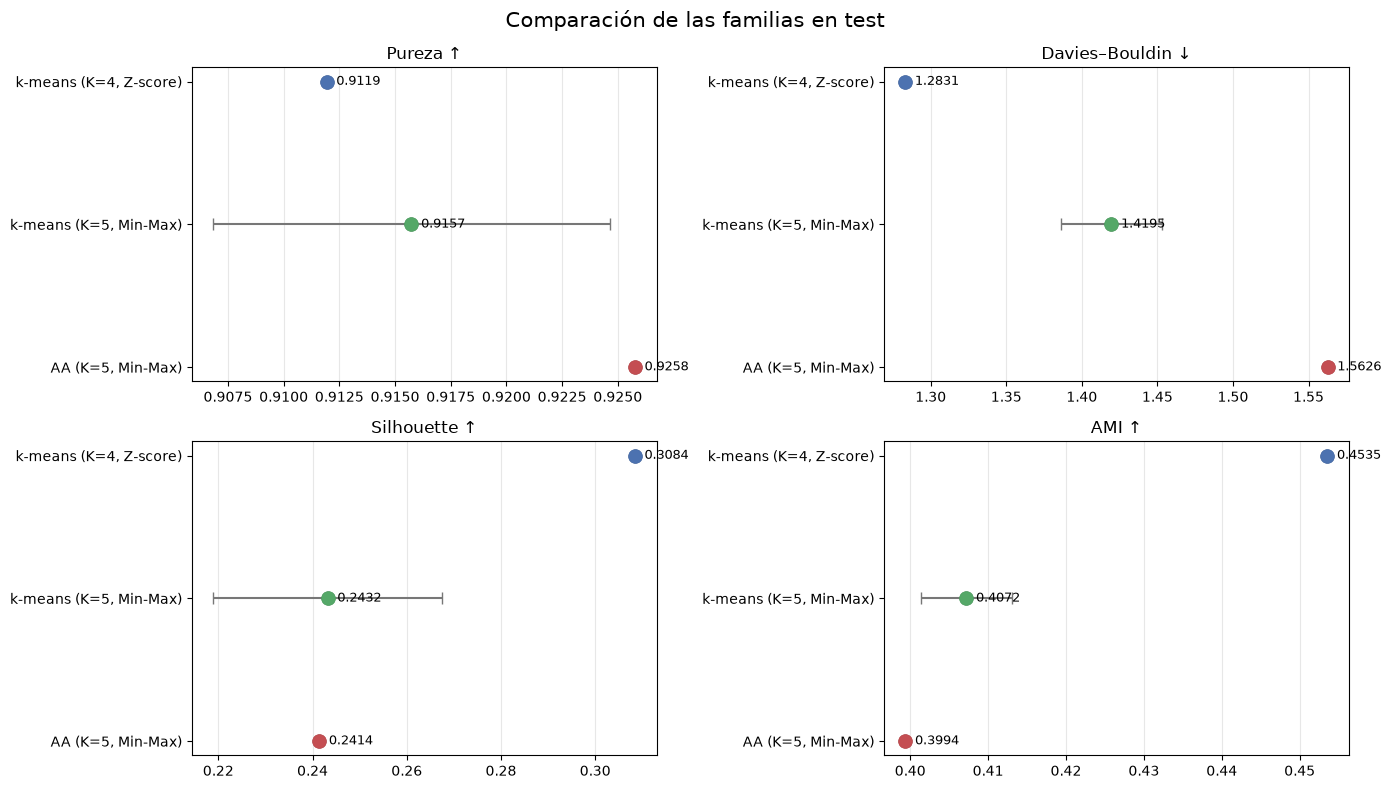

Figura guardada en: C:\Users\adanm\Code\tesis\resultados\evaluacion_test_corregida\figuras\comparacion_metricas_test.png


In [22]:
# Directorio para las figuras finales
RUTA_FIGURAS_TEST = (
    RUTA_RESULTADOS_TEST
    / "figuras"
)

RUTA_FIGURAS_TEST.mkdir(
    parents=True,
    exist_ok=True,
)


# Orden y colores consistentes entre paneles
orden_grafico = [
    "k-means (K=4, Z-score)",
    "k-means (K=5, Min-Max)",
    "AA (K=5, Min-Max)",
]

colores = [
    "#4C72B0",
    "#55A868",
    "#C44E52",
]


# Preparar datos numéricos para el gráfico
df_grafico_test = (
    df_resumen_test_completo
    .assign(
        familia=lambda tabla: (
            tabla["familia_test"]
            .map(nombres_familias)
        )
    )
    .set_index("familia")
    .loc[orden_grafico]
    .reset_index()
)


metricas_grafico = [
    (
        "purity_test_media",
        "purity_test_std",
        "Pureza ↑",
    ),
    (
        "davies_bouldin_test_media",
        "davies_bouldin_test_std",
        "Davies–Bouldin ↓",
    ),
    (
        "silhouette_test_media",
        "silhouette_test_std",
        "Silhouette ↑",
    ),
    (
        "ami_test_media",
        "ami_test_std",
        "AMI ↑",
    ),
]


fig, ejes = plt.subplots(
    2,
    2,
    figsize=(14, 8),
)

posiciones = np.arange(
    len(df_grafico_test)
)


for eje, (
    columna_media,
    columna_std,
    titulo,
) in zip(ejes.flat, metricas_grafico):

    medias = df_grafico_test[
        columna_media
    ].to_numpy()

    desviaciones = df_grafico_test[
        columna_std
    ].to_numpy()

    eje.errorbar(
        medias,
        posiciones,
        xerr=desviaciones,
        fmt="o",
        markersize=9,
        capsize=4,
        color="#333333",
        ecolor="#777777",
    )

    for posicion, valor, color in zip(
        posiciones,
        medias,
        colores,
    ):
        eje.scatter(
            valor,
            posicion,
            s=90,
            color=color,
            zorder=3,
        )

        eje.annotate(
            f"{valor:.4f}",
            xy=(valor, posicion),
            xytext=(7, 0),
            textcoords="offset points",
            va="center",
            fontsize=9,
        )

    eje.set_yticks(posiciones)
    eje.set_yticklabels(
        df_grafico_test["familia"]
    )
    eje.invert_yaxis()
    eje.set_title(titulo)
    eje.grid(
        axis="x",
        alpha=0.3,
    )


fig.suptitle(
    "Comparación de las familias en test",
    fontsize=15,
)

fig.tight_layout()

ruta_figura_metricas = (
    RUTA_FIGURAS_TEST
    / "comparacion_metricas_test.png"
)

fig.savefig(
    ruta_figura_metricas,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figura guardada en: {ruta_figura_metricas}"
)

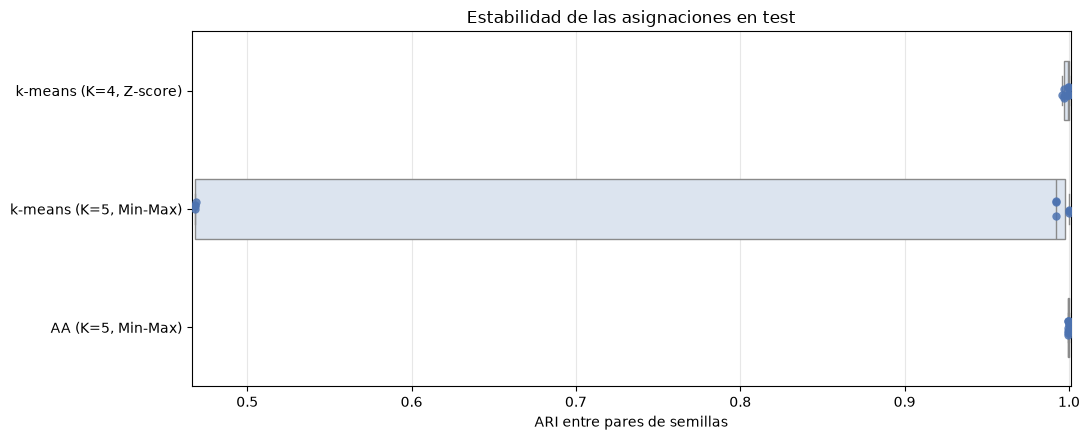

Figura guardada en: C:\Users\adanm\Code\tesis\resultados\evaluacion_test_corregida\figuras\estabilidad_ari_test.png


In [23]:
# Preparar las comparaciones individuales de estabilidad
df_grafico_ari = (
    df_ari_test_detalle
    .assign(
        familia=lambda tabla: (
            tabla["familia_test"]
            .map(nombres_familias)
        )
    )
)


orden_estabilidad = [
    "k-means (K=4, Z-score)",
    "k-means (K=5, Min-Max)",
    "AA (K=5, Min-Max)",
]


fig, eje = plt.subplots(
    figsize=(11, 4.5)
)


sns.boxplot(
    data=df_grafico_ari,
    x="ari_test",
    y="familia",
    order=orden_estabilidad,
    color="#D9E4F2",
    width=0.5,
    showfliers=False,
    ax=eje,
)

sns.stripplot(
    data=df_grafico_ari,
    x="ari_test",
    y="familia",
    order=orden_estabilidad,
    color="#4C72B0",
    size=6,
    jitter=0.08,
    alpha=0.85,
    ax=eje,
)


eje.set_xlim(
    df_grafico_ari["ari_test"].min() - 0.002,
    1.001,
)

eje.set_xlabel(
    "ARI entre pares de semillas"
)

eje.set_ylabel("")

eje.set_title(
    "Estabilidad de las asignaciones en test"
)

eje.grid(
    axis="x",
    alpha=0.3,
)

fig.tight_layout()


ruta_figura_estabilidad = (
    RUTA_FIGURAS_TEST
    / "estabilidad_ari_test.png"
)

fig.savefig(
    ruta_figura_estabilidad,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figura guardada en: "
    f"{ruta_figura_estabilidad}"
)

In [24]:
# Guardar la comparación entre validación y test
df_comparacion_val_test.to_csv(
    RUTA_RESULTADOS_TEST
    / "comparacion_validacion_test.csv",
    index=False,
)


# Guardar la tabla legible utilizada en el informe
tabla_final_mostrar.to_csv(
    RUTA_RESULTADOS_TEST
    / "tabla_comparativa_test.csv",
    index=False,
)


# Verificar los archivos principales generados
archivos_resultados = sorted(
    ruta.name
    for ruta in RUTA_RESULTADOS_TEST.iterdir()
    if ruta.is_file()
)

archivos_figuras = sorted(
    ruta.name
    for ruta in RUTA_FIGURAS_TEST.iterdir()
    if ruta.is_file()
)


print("Archivos de resultados:")
for archivo in archivos_resultados:
    print(f"- {archivo}")


print("\nFiguras:")
for archivo in archivos_figuras:
    print(f"- {archivo}")

Archivos de resultados:
- ari_test_detalle.csv
- ari_test_resumen.csv
- comparacion_validacion_test.csv
- ids_test.npy
- metricas_test_ejecuciones.csv
- metricas_test_resumen.csv
- tabla_comparativa_test.csv

Figuras:
- comparacion_metricas_test.png
- estabilidad_ari_test.png


## Conclusiones de la evaluación en test

Las tres configuraciones evaluadas conservaron en test un comportamiento consistente con el observado durante la validación. El MSE aumentó entre un 0,53 % y un 1,05 %, mientras que los cambios en pureza, Davies–Bouldin, silhouette y AMI fueron pequeños.

La configuración principal de k-means, basada en `medianas_fase_50`, normalización `zscore`, inicialización `k-means++` y \(K=4\), obtuvo el mejor Davies–Bouldin (1,2831), silhouette (0,3084) y AMI (0,4535). También presentó una estabilidad elevada entre semillas, con un ARI medio de 0,9984.

La comparación controlada utilizó `medianas_fase_50`, normalización `minmax` y \(K=5\) tanto para AA como para k-means. En estas condiciones, AA obtuvo un MSE de 0,004019 frente a 0,006494 de k-means, lo que representa una reducción aproximada del 38,1 % en el error de reconstrucción. AA también alcanzó una pureza mayor (0,9258 frente a 0,9157) y una estabilidad considerablemente superior, con un ARI medio de 0,9997 frente a 0,7849.

Por otra parte, k-means con Min-Max y \(K=5\) obtuvo un mejor Davies–Bouldin (1,4195 frente a 1,5626), además de valores ligeramente superiores de silhouette (0,2432 frente a 0,2414) y AMI (0,4072 frente a 0,3994). Sin embargo, mostró una alta variabilidad entre semillas y alcanzó un ARI mínimo de 0,4682, lo que indica que algunas inicializaciones condujeron a particiones diferentes.

El MSE y el RSS pueden compararse directamente entre AA y k-means con \(K=5\) porque ambas configuraciones utilizan la misma representación y normalización. Estas métricas no se compararon con el k-means principal de \(K=4\), ya que utiliza Z-score y, por lo tanto, trabaja en una escala diferente.

En conjunto, k-means con \(K=4\) presentó la mejor separación y asociación con los subtipos como método de agrupamiento duro. AA destacó por su menor error de reconstrucción, mayor pureza y mayor estabilidad en la comparación controlada. Sin embargo, estas métricas utilizan la asignación producida por el coeficiente \(\alpha\) máximo y no consideran toda la información continua de la representación arquetípica. Por esta razón, el análisis posterior examinará los arquetipos, los vectores de coeficientes \(\alpha\), las observaciones mixtas y los posibles casos atípicos.